In [ ]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Multilayer Perceptron
import pandas as pd
import numpy
# fix random seed for reproducibility
seed = 7
numpy.random.seed(seed)
import tensorflow as tf



import tensorflow.keras
import math
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2DTranspose,Input, Reshape, Conv2D, Flatten
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error
from tensorflow.keras.layers import concatenate, BatchNormalization
import argparse
#from tensorflow.keras.utils.np_utils import to_categorical
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Dropout
import numpy as np
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold
from scipy.stats import pearsonr, spearmanr
from skimage import io

c:\Users\14792\anaconda3\envs\ComputerVision\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


In [2]:
####################
####### Functions #############
####################

def custom_loss_2 (y_true, y_pred):
    A = tensorflow.keras.losses.mean_absolute_error(y_true, y_pred)
    #B = keras.losses.categorical_crossentropy(y_true[:,-4:], y_pred[:,-4:])
    return A





def lrelu(x): #from pix2pix code
    a=0.2
    # adding these together creates the leak part and linear part
    # then cancels them out by subtracting/adding an absolute value term
    # leak: a*x/2 - a*abs(x)/2
    # linear: x/2 + abs(x)/2

    # this block looks like it has 2 inputs on the graph unless we do this
    x = tf.identity(x)
    return (0.5 * (1 + a)) * x + (0.5 * (1 - a)) * tf.abs(x)

def lrelu_output_shape(input_shape):
    shape = list(input_shape)
    return tuple(shape)

from tensorflow.keras.layers import Lambda
layer_lrelu=Lambda(lrelu, output_shape=lrelu_output_shape, name='Leaky_ReLU')


def createOutputLabels(Labels):
    output=np.zeros(shape=(len(Labels),12))    
    
    for i in range(len(Labels)):
        for j in range (4):
            if Labels.iloc[i,j]=='CN':
                output[i,j*3]=1
                output[i,j*3+1]=0
                output[i,j*3+2]=0

                
            elif Labels.iloc[i,j]=='MCI':
                output[i,j*3]=0
                output[i,j*3+1]=1
                output[i,j*3+2]=0
                
            elif Labels.iloc[i,j]=='Dementia':
                output[i,j*3]=0
                output[i,j*3+1]=0
                output[i,j*3+2]=1
                
            # plt.figure()
            # plt.imshow(OutputImages[19,:,:,:])
    return output

def create_image(labels):
    output=np.zeros(shape=(len(labels),3,4,3))    
    
    for i in range(len(labels)):
        for j in range (3):
                if j ==0:
                    output[i,j,:,1] = labels[i,j]
                elif j==1:
                     output[i,j,:,2] = labels[i,j]
                elif j ==2:
                    output[i,j,:,0] = labels[i,j]

                
            # plt.figure()
            # plt.imshow(OutputImages[19,:,:,:])
    return output



def FnCreateValidLabes(Labels):
    return range(len(Labels))

In [8]:
n_splits=10


In [3]:
####################
###### Reading Data ##############    
####################    

# AllDataset = pandas.read_csv('Data_XY_BLD_CutOff.csv', low_memory=False)
AllDataset = pd.read_csv('dataset_imputed.csv', low_memory=False)
AllDataset = AllDataset.set_index(AllDataset.ID)


AllDataset.columns

Index(['ID', 'RID', 'PTID', 'VISCODE', 'SITE', 'COLPROT', 'ORIGPROT',
       'EXAMDATE', 'DX_bl', 'AGE', 'PTGENDER', 'PTEDUCAT', 'PTETHCAT',
       'PTRACCAT', 'PTMARRY', 'APOE4', 'FDG', 'PIB', 'AV45', 'ABETA', 'TAU',
       'PTAU', 'CDRSB', 'ADAS11', 'ADAS13', 'ADASQ4', 'MMSE',
       'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting',
       'RAVLT_perc_forgetting', 'LDELTOTAL', 'DIGITSCOR', 'TRABSCOR', 'FAQ',
       'MOCA', 'EcogPtMem', 'EcogPtLang', 'EcogPtVisspat', 'EcogPtPlan',
       'EcogPtOrgan', 'EcogPtDivatt', 'EcogPtTotal', 'EcogSPMem', 'EcogSPLang',
       'EcogSPVisspat', 'EcogSPPlan', 'EcogSPOrgan', 'EcogSPDivatt',
       'EcogSPTotal', 'FLDSTRENG', 'FSVERSION', 'IMAGEUID', 'Ventricles',
       'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV',
       'Unnamed: 60', 'Unnamed: 61', 'DX', '6', 'DX6', '12', 'DX12', '24',
       'DX24'],
      dtype='object')

In [5]:
len(AllDataset)

5660

In [4]:
regions = ['Ventricles', 'Hippocampus', 'WholeBrain', 
              'Entorhinal', 'Fusiform', 'MidTemp', 'ICV']
volume_means = AllDataset.groupby('DX')[regions].mean().round(4)
volume_means

,Ventricles,Hippocampus,WholeBrain,Entorhinal,Fusiform,MidTemp,ICV
DX,,,,,,,
CN,36415.8895,7223.0629,1.017197e+06,3768.4489,17634.6637,19907.1495,1.516962e+06
Dementia,54544.1594,5491.3523,9.559477e+05,2718.4622,15021.5731,16639.5407,1.541326e+06
MCI,42038.7636,6752.3339,1.028269e+06,3540.5969,17499.9122,19590.9377,1.545141e+06


In [5]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1385, 'missing_counts': Ventricles      63
Hippocampus    102
WholeBrain      47
Entorhinal     124
Fusiform       124
MidTemp        124
ICV             35
dtype: int64}, 'Dementia': {'total_subjects': 2216, 'missing_counts': Ventricles     194
Hippocampus    388
WholeBrain     158
Entorhinal     515
Fusiform       515
MidTemp        515
ICV            116
dtype: int64}, 'MCI': {'total_subjects': 2059, 'missing_counts': Ventricles      62
Hippocampus    147
WholeBrain      37
Entorhinal     206
Fusiform       206
MidTemp        206
ICV             19
dtype: int64}}


In [6]:
AllDataset[regions].head(7)

,Ventricles,Hippocampus,WholeBrain,Entorhinal,Fusiform,MidTemp,ICV
ID,,,,,,,
1,118233.0,8336.0,1229740.0,4177.0,16559.0,27936.0,1984660.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,84599.0,5319.0,1129830.0,1791.0,15506.0,18422.0,1920690.0


In [7]:
for region in regions:
    AllDataset[region] = AllDataset.groupby('DX')[region].transform(
        lambda group: group.fillna(group.mean())
    )

AllDataset[regions].head(7)

,Ventricles,Hippocampus,WholeBrain,Entorhinal,Fusiform,MidTemp,ICV
ID,,,,,,,
1,118233.000000,8336.000000,1.229740e+06,4177.000000,16559.000000,27936.000000,1.984660e+06
2,36415.889497,7223.062938,1.017197e+06,3768.448887,17634.663661,19907.149483,1.516962e+06
3,36415.889497,7223.062938,1.017197e+06,3768.448887,17634.663661,19907.149483,1.516962e+06
4,36415.889497,7223.062938,1.017197e+06,3768.448887,17634.663661,19907.149483,1.516962e+06
5,36415.889497,7223.062938,1.017197e+06,3768.448887,17634.663661,19907.149483,1.516962e+06
6,36415.889497,7223.062938,1.017197e+06,3768.448887,17634.663661,19907.149483,1.516962e+06
7,84599.000000,5319.000000,1.129830e+06,1791.000000,15506.000000,18422.000000,1.920690e+06


In [8]:
###################### MRI ######################
MRI_X = AllDataset.loc[:,['Ventricles', 'Hippocampus', 'WholeBrain', 'Entorhinal', 'Fusiform', 'MidTemp', 'ICV']]
p=MRI_X.values

MRI_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
MRI_ID = AllDataset.ID
# normalize data
MRI_X = (MRI_X - MRI_X.min())/ (MRI_X.max() - MRI_X.min())
#MRI_X=MRI_X+1
MRI_X.head(10)

,Ventricles,Hippocampus,WholeBrain,Entorhinal,Fusiform,MidTemp,ICV
ID,,,,,,,
1,0.627305,0.681473,0.693769,0.428896,0.420717,0.823856,0.924711
2,0.171426,0.560090,0.439819,0.405483,0.461159,0.491329,0.644423
3,0.171426,0.560090,0.439819,0.405483,0.461159,0.491329,0.644423
4,0.171426,0.560090,0.439819,0.405483,0.461159,0.491329,0.644423
5,0.171426,0.560090,0.439819,0.405483,0.461159,0.491329,0.644423
6,0.171426,0.560090,0.439819,0.405483,0.461159,0.491329,0.644423
7,0.439899,0.352420,0.574395,0.292161,0.381128,0.429820,0.886374
8,0.462081,0.366272,0.538825,0.328609,0.339545,0.369766,0.877828
9,0.470544,0.334752,0.533544,0.280986,0.347704,0.384593,0.876264


In [9]:
regions = ['FDG', 'AV45']
means = AllDataset.groupby('DX')[regions].mean().round(4)
means

,FDG,AV45
DX,,
CN,1.3016,1.0992
Dementia,1.0564,1.3746
MCI,1.2410,1.1772


In [10]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1385, 'missing_counts': FDG     631
AV45    571
dtype: int64}, 'Dementia': {'total_subjects': 2216, 'missing_counts': FDG     1232
AV45    1708
dtype: int64}, 'MCI': {'total_subjects': 2059, 'missing_counts': FDG     840
AV45    960
dtype: int64}}


In [11]:
for region in regions:
    AllDataset[region] = AllDataset.groupby('DX')[region].transform(
        lambda group: group.fillna(group.mean())
    )

In [12]:
###################### PET ######################
PET_X = AllDataset.loc[:,['FDG', 'AV45']]
PET_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
PET_ID = AllDataset.ID


# normalize data
PET_X = (PET_X - PET_X.min()) / (PET_X.max() - PET_X.min())
PET_X.head(5)

,FDG,AV45
ID,,
1,0.681943,0.156534
2,0.551275,0.156534
3,0.628132,0.156534
4,0.628132,0.156534
5,0.628132,0.156534


In [13]:
regions = ['CDRSB', 'MMSE', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting', 
                           'RAVLT_perc_forgetting','FAQ', 'MOCA', 'LDELTOTAL', 'DIGITSCOR',
                            'TRABSCOR']
means = AllDataset.groupby('DX')[regions].mean().round(4)
means

,CDRSB,MMSE,RAVLT_immediate,RAVLT_learning,RAVLT_forgetting,RAVLT_perc_forgetting,FAQ,MOCA,LDELTOTAL,DIGITSCOR,TRABSCOR
DX,,,,,,,,,,,
CN,0.0804,29.1118,45.8723,5.9152,3.4304,31.5372,0.2190,26.0832,14.1002,48.6347,79.0275
Dementia,5.7874,21.5538,20.6660,1.7025,4.2982,92.7523,16.2858,16.5834,1.5108,26.9979,205.9841
MCI,1.5450,27.6103,34.7739,4.1498,4.6806,60.8946,3.3074,24.0972,7.1691,38.9892,112.8620


In [14]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1385, 'missing_counts': CDRSB                      1
MMSE                       0
RAVLT_immediate            0
RAVLT_learning             0
RAVLT_forgetting           0
RAVLT_perc_forgetting      0
FAQ                        1
MOCA                     213
LDELTOTAL                  0
DIGITSCOR                513
TRABSCOR                   0
dtype: int64}, 'Dementia': {'total_subjects': 2216, 'missing_counts': CDRSB                       5
MMSE                        4
RAVLT_immediate            22
RAVLT_learning             22
RAVLT_forgetting           30
RAVLT_perc_forgetting      53
FAQ                         5
MOCA                     1131
LDELTOTAL                 211
DIGITSCOR                 779
TRABSCOR                  148
dtype: int64}, 'MCI': {'total_subjects': 2059, 'missing_counts': CDRSB                       0
MMSE                        0
RAVLT_immediate             0
RAVLT_learning              0
RAVLT_forgetting            0
RAVLT_perc_forge

In [15]:
for region in regions:
    AllDataset[region] = AllDataset.groupby('DX')[region].transform(
        lambda group: group.fillna(group.mean())
    )

In [16]:
###################### COG ######################
COG_X = AllDataset.loc[:, ['CDRSB', 'MMSE', 'RAVLT_immediate', 'RAVLT_learning', 'RAVLT_forgetting', 
                           'RAVLT_perc_forgetting','FAQ', 'MOCA', 'LDELTOTAL', 'DIGITSCOR',
                            'TRABSCOR']]




COG_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
COG_RID = AllDataset.ID

# normalize data
COG_X = (COG_X - COG_X.min()) / (COG_X.max() - COG_X.min())
COG_X.head()

,CDRSB,MMSE,RAVLT_immediate,RAVLT_learning,RAVLT_forgetting,RAVLT_perc_forgetting,FAQ,MOCA,LDELTOTAL,DIGITSCOR,TRABSCOR
ID,,,,,,,,,,,
1,0.0,0.943981,0.641868,0.473684,0.666667,0.526051,0.051678,0.660016,0.479167,0.691293,0.262282
2,0.0,0.943981,0.595658,0.421053,0.555556,0.509881,0.051678,0.653142,0.532112,0.659631,0.271518
3,0.0,0.971991,0.526342,0.368421,0.703704,0.557312,0.051678,0.618774,0.583333,0.686016,0.272940
4,0.0,0.943981,0.561000,0.526316,0.592593,0.512253,0.051678,0.584265,0.548611,0.687463,0.300650
5,0.0,0.803934,0.618763,0.421053,0.629630,0.527009,0.051678,0.567745,0.618056,0.689676,0.228177


In [17]:
regions = ['ABETA', 'PTAU', 'TAU']
means = AllDataset.groupby('DX')[regions].mean().round(4)
means

,ABETA,PTAU,TAU
DX,,,
CN,1203.6011,22.8863,247.8811
Dementia,635.1081,35.3799,360.8127
MCI,973.9756,27.5085,287.7333


In [18]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1385, 'missing_counts': ABETA    679
PTAU     679
TAU      679
dtype: int64}, 'Dementia': {'total_subjects': 2216, 'missing_counts': ABETA    1477
PTAU     1477
TAU      1477
dtype: int64}, 'MCI': {'total_subjects': 2059, 'missing_counts': ABETA    1068
PTAU     1069
TAU      1068
dtype: int64}}


In [19]:
for region in regions:
    AllDataset[region] = AllDataset.groupby('DX')[region].transform(
        lambda group: group.fillna(group.mean())
    )

In [20]:
###################### CSF ######################
CSF_X = AllDataset.loc[:,['ABETA', 'PTAU', 'TAU']]
CSF_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
CSF_RID = AllDataset.ID


# normalize data
CSF_X = (CSF_X - CSF_X.min()) / (CSF_X.max() - CSF_X.min())
CSF_X.head()

,ABETA,PTAU,TAU
ID,,,
1,0.522523,0.150544,0.194075
2,0.522523,0.150544,0.194075
3,0.522523,0.150544,0.194075
4,0.522523,0.150544,0.194075
5,0.522523,0.150544,0.194075


In [21]:
regions = ['AGE','PTEDUCAT']
means = AllDataset.groupby('DX')[regions].mean().round(4)
means

,AGE,PTEDUCAT
DX,,
CN,76.3256,16.4368
Dementia,76.5736,15.4558
MCI,74.5069,15.9917


In [22]:
missing_analysis = {}
    
# Get unique DX values
dx_groups = AllDataset['DX'].unique()

# For each diagnosis group
for dx in dx_groups:
    dx_data = AllDataset[AllDataset['DX'] == dx]
    total_in_group = len(dx_data)
    
    # Get missing counts for each region
    missing_counts = dx_data[regions].isnull().sum()
    missing_percentages = (missing_counts / total_in_group * 100).round(2)
    
    missing_analysis[dx] = {
        'total_subjects': total_in_group,
        'missing_counts': missing_counts,
    }

print(missing_analysis)

{'CN': {'total_subjects': 1385, 'missing_counts': AGE         0
PTEDUCAT    0
dtype: int64}, 'Dementia': {'total_subjects': 2216, 'missing_counts': AGE         0
PTEDUCAT    0
dtype: int64}, 'MCI': {'total_subjects': 2059, 'missing_counts': AGE         0
PTEDUCAT    0
dtype: int64}}


In [23]:
###################### Risk Factor ######################
RF_X_1 = AllDataset.loc[:,['AGE','PTEDUCAT']]

RF_X_A = AllDataset.loc[:,['APOE4']]# ,'PTEDUCAT']] 


RF_X_gender = AllDataset.loc[:,['PTGENDER']]
RF_X_gender[RF_X_gender=='Male']=1
RF_X_gender[RF_X_gender=='Female']=2
RF_X_gender=RF_X_gender.fillna(3)

RF_X_ethnicity = AllDataset.loc[:,['PTETHCAT']]
RF_X_ethnicity[RF_X_ethnicity=='Not Hisp/Latino']=1
RF_X_ethnicity[RF_X_ethnicity=='Hisp/Latino']=2
RF_X_ethnicity[RF_X_ethnicity=='Unknown']=3
RF_X_ethnicity=RF_X_ethnicity.fillna(3)

RF_X_race = AllDataset.loc[:,['PTRACCAT']]
RF_X_race[RF_X_race=='White']=1
RF_X_race[RF_X_race=='Black']=2
RF_X_race[RF_X_race=='Asian']=3
RF_X_race[RF_X_race=='Am Indian/Alaskan']=4
RF_X_race[RF_X_race=='Hawaiian/Other PI']=5
RF_X_race[RF_X_race=='More than one']=6
RF_X_race[RF_X_race=='Unknown']=7
RF_X_race=RF_X_race.fillna(7)

RF_X_marry = AllDataset.loc[:,['PTMARRY']]
RF_X_marry[RF_X_marry=='Married']=1
RF_X_marry[RF_X_marry=='Widowed']=2
RF_X_marry[RF_X_marry=='Divorced']=3
RF_X_marry[RF_X_marry=='Never married']=4
RF_X_marry[RF_X_marry=='Unknown']=5
RF_X_marry=RF_X_marry.fillna(5)

import pandas as pd
# RF_X = pd.concat([RF_X_1, RF_X_A, RF_X_gender, RF_X_marry ], axis=1)#, RF_X_sex
RF_X = pd.concat([RF_X_1, RF_X_A, RF_X_gender, RF_X_ethnicity, RF_X_race, RF_X_marry ], axis=1)#, RF_X_sex



# normalize data
RF_X = (RF_X - RF_X.min()) / (RF_X.max() - RF_X.min())


RF_Y = AllDataset.loc[:, ['DX', 'DX6','DX12', 'DX24']]#
RF_ID = AllDataset.ID

RF_X.head()

,AGE,PTEDUCAT,APOE4,PTGENDER,PTETHCAT,PTRACCAT,PTMARRY
ID,,,,,,,
1,0.470732,0.75,0.0,0.0,0.0,0.0,0.0
2,0.482927,0.75,0.0,0.0,0.0,0.0,0.0
3,0.543902,0.75,0.0,0.0,0.0,0.0,0.0
4,0.592683,0.75,0.0,0.0,0.0,0.0,0.0
5,0.617073,0.75,0.0,0.0,0.0,0.0,0.0


In [24]:
########################################
############## dataset cleaning #######
########################################

Labels_all_3class=COG_Y.iloc[:,-4:]

Labels_all_3class


,DX,DX6,DX12,DX24
ID,,,,
1,CN,CN,CN,CN
2,CN,CN,CN,CN
3,CN,CN,CN,CN
4,CN,CN,CN,MCI
5,CN,CN,CN,CN
...,...,...,...,...
5656,Dementia,Dementia,Dementia,Dementia
5657,Dementia,Dementia,Dementia,Dementia
5658,Dementia,Dementia,Dementia,Dementia


In [25]:
########################################
############## genreating input outputs from data #######
########################################

TargetTensors=createOutputLabels(Labels_all_3class)
#plt.imshow(TargetTensors[11,:,:,:])
#print(Labels_all_4class.iloc[11])


X_all=[MRI_X.values, PET_X.values, COG_X.values, 
       CSF_X.values, RF_X.values]

YTrain = COG_Y
YTrain1 = YTrain.reset_index()
Y_all_tensors=TargetTensors
X_all_IDs=RF_ID.values

In [26]:
from tensorflow.keras import backend as K

def grouped_softmax(x):
    """
    Activation function that applies softmax separately to groups of neurons
    Groups: [0-2], [3-5], [6-8], [9-11]
    
    Args:
        x: Input tensor
        
    Returns:
        Tensor with grouped softmax applied
    """
    groups = [(0, 3), (3, 6), (6, 9), (9, 12)]
    group_outputs = []
    
    # Apply softmax to each group
    for start, end in groups:
        group = x[..., start:end]
        group_softmax = K.softmax(group, axis=-1)
        group_outputs.append(group_softmax)
    
    # Concatenate all groups back together
    return K.concatenate(group_outputs, axis=-1)

In [ ]:
######################################################################################
################## NEtwork Architecture ##################################################
##########################################################################################

####################################### MRI FCN ###############################################
# mri FCN
MRI_inp_dim = MRI_X.shape[1]
MRI_visible = Input(shape=(MRI_inp_dim,), name='MRI')
hiddenMRI1 = Dense(50, activation='relu')(MRI_visible)
hiddenMRI1 = Dropout(0.2)(hiddenMRI1)
MRI_output = Dense(150, activation='relu')(hiddenMRI1)

####################################### PET FCN ###############################################
PET_inp_dim = PET_X.shape[1]
PET_visible = Input(shape=(PET_inp_dim,), name='PET')
hiddenPET2 = Dense(50, activation='relu')(PET_visible)
hiddenPET2 = Dropout(0.2)(hiddenPET2)
PET_output = Dense(150, activation='relu')(hiddenPET2)

####################################### COG FCN ###############################################
# mri FCN
COG_inp_dim = COG_X.shape[1]
COG_visible = Input(shape=(COG_inp_dim,), name='COG')
hiddenCOG1 = Dense(50, activation='relu')(COG_visible)
hiddenCOG1 = Dropout(0.2)(hiddenCOG1)
COG_output = Dense(150, activation='relu')(hiddenCOG1)

####################################### CSF FCN ###############################################
CSF_inp_dim = CSF_X.shape[1]
CSF_visible = Input(shape=(CSF_inp_dim,), name='CSF')
hiddenCSF2 = Dense(50, activation='relu')(CSF_visible)
hiddenCSF2 = Dropout(0.2)(hiddenCSF2)
CSF_output = Dense(150, activation='relu')(hiddenCSF2)

####################################### RF FCN ###############################################
RF_inp_dim = RF_X.shape[1]
RF_visible = Input(shape=(RF_inp_dim,), name='RF')
hiddenRF1 = Dense(50, activation='relu')(RF_visible)
hiddenRF1 = Dropout(0.2)(hiddenRF1)
RF_output = Dense(150, activation='relu')(hiddenRF1)

#################################### Concat FCN ###############################################

merge = concatenate([MRI_output, PET_output, COG_output, CSF_output,RF_output])
merge = BatchNormalization()(merge)
merge = Dropout(0.2)(merge)
# interpretation layer
hidden1 = Dense(512, activation='relu')(merge)
hidden1 = Dropout(0.2)(hidden1)

hidden2 = Dense(256, activation='relu')(hidden1)
hidden2 = Dropout(0.2)(hidden2)

hidden3 = Dense(128, activation='relu')(hidden2)
hidden3 = Dropout(0.2)(hidden3)

hidden4 = Dense(64, activation='relu')(hidden3)
hidden4 = Dropout(0.2)(hidden4)

# hidden5 = Dense(32, activation='relu')(hidden4)
# hidden5 = Dropout(0.2)(hidden5)

output = Dense(12, activation = grouped_softmax)(hidden4)
model_tensorization=Model(inputs= [MRI_visible, PET_visible, COG_visible, CSF_visible, RF_visible], outputs=output)  



model_tensorization.summary()
#dot_img_file = 'Network_23x23.png'


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 MRI (InputLayer)               [(None, 7)]          0           []                               
                                                                                                  
 PET (InputLayer)               [(None, 2)]          0           []                               
                                                                                                  
 COG (InputLayer)               [(None, 11)]         0           []                               
                                                                                                  
 CSF (InputLayer)               [(None, 3)]          0           []                               
                                                                                            

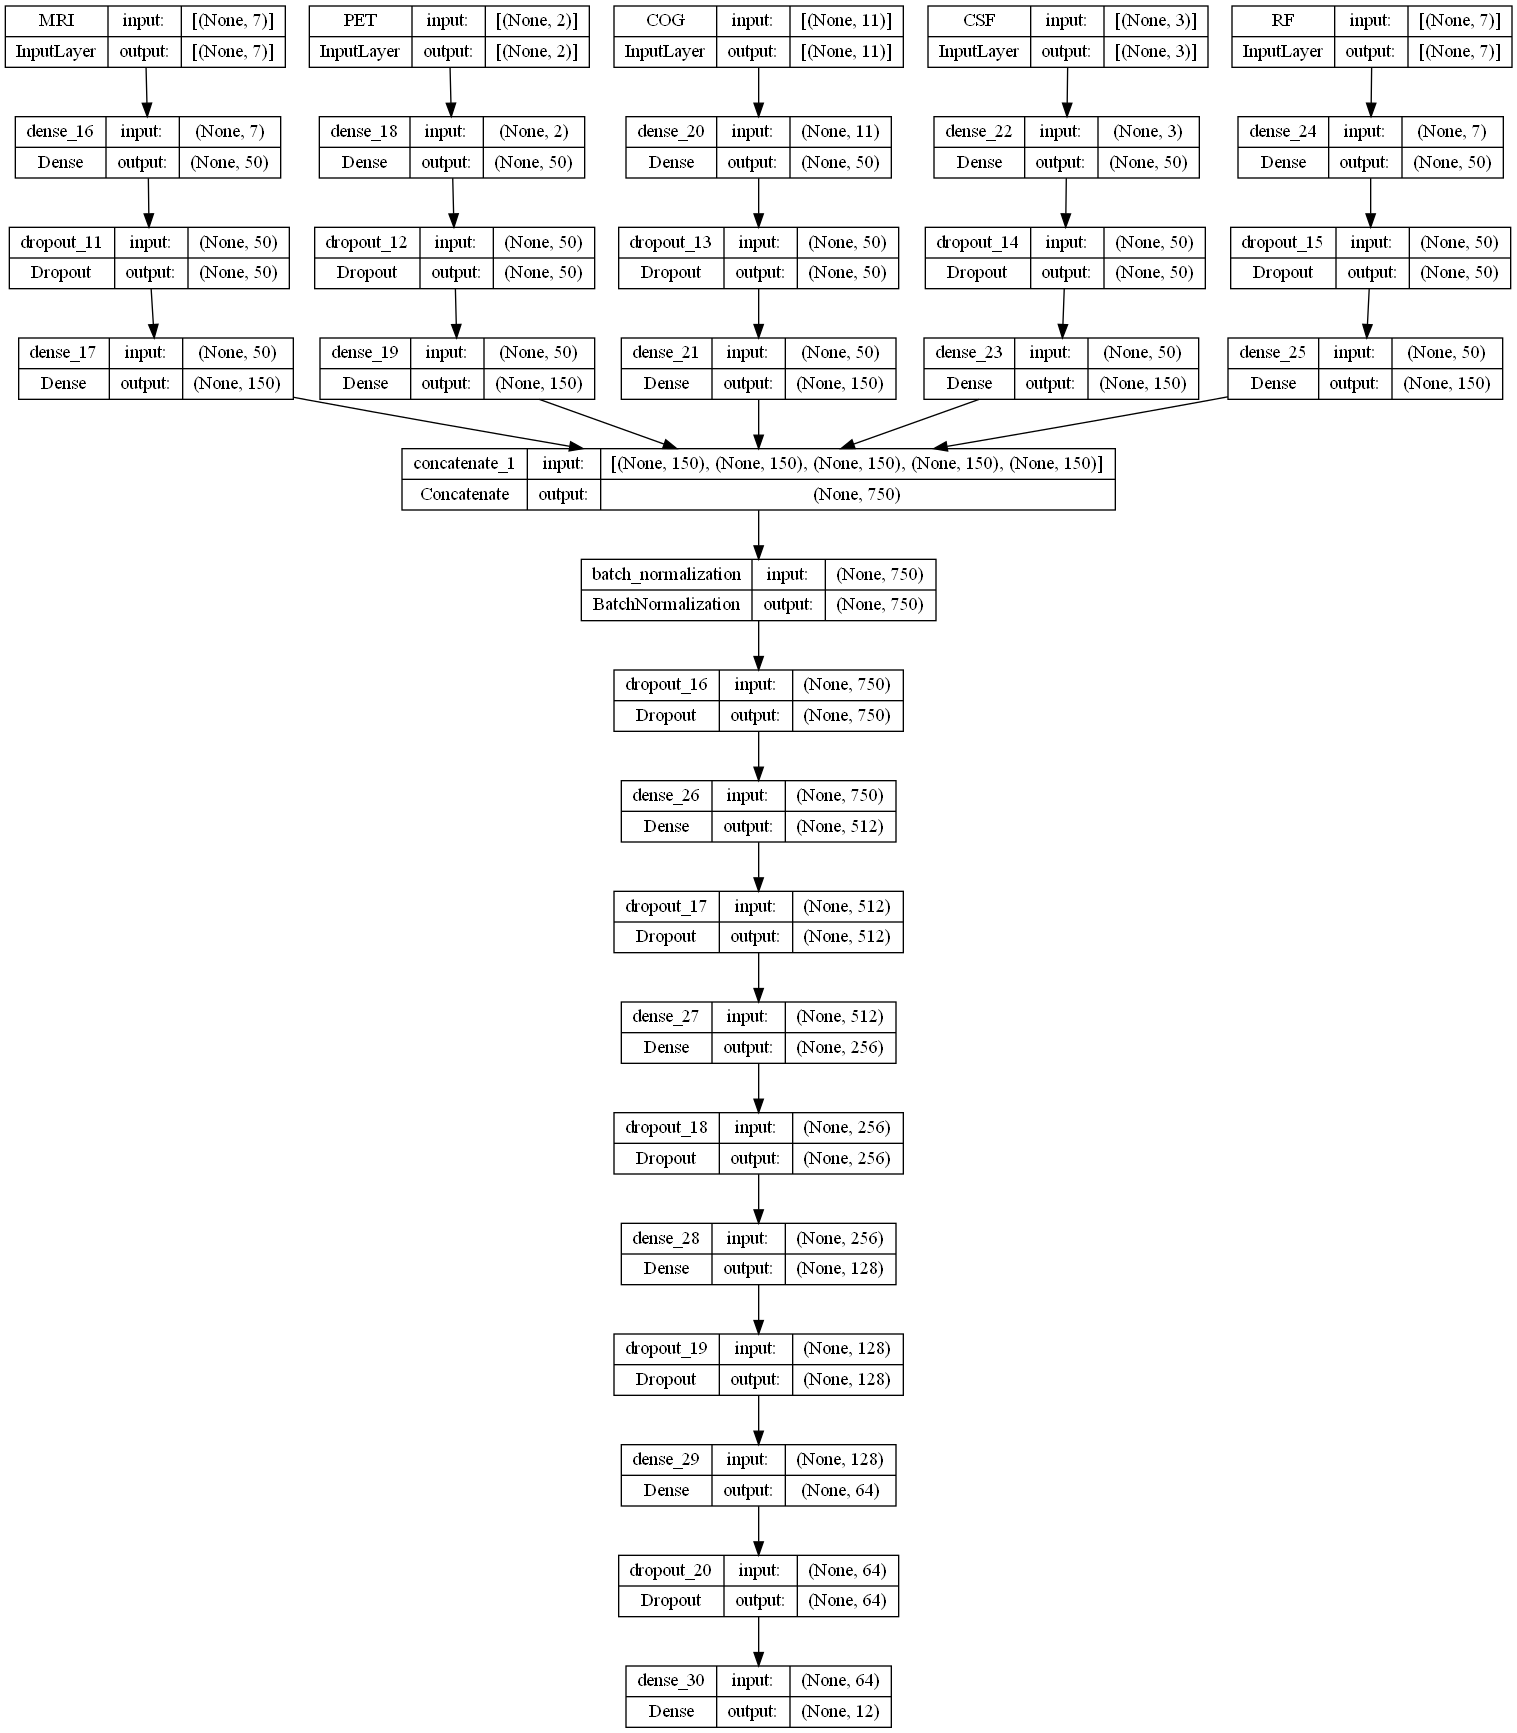

In [34]:
from tensorflow.keras.utils import plot_model

# Save the model architecture as a PNG file
plot_model(model_tensorization, to_file='model_tree.png', show_shapes=True, show_layer_names=True)

In [29]:
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy

def grouped_categorical_crossentropy(y_true, y_pred):
    """
    Custom loss function that calculates average categorical cross entropy for groups of outputs.
    Groups: [0-2], [3-5], [6-8], [9-11]
    
    Args:
        y_true: Ground truth values, shape (batch_size, num_classes)
        y_pred: Predicted values, shape (batch_size, num_classes)
        
    Returns:
        Average of categorical cross entropy losses across the groups
    """
    # Initialize categorical cross entropy loss function
    cce = CategoricalCrossentropy(from_logits=False, reduction=tf.keras.losses.Reduction.NONE)
    
    # Define groups of indices
    groups = [(0, 3), (3, 6), (6, 9), (9, 12)]
    
    # Compute CCE loss for each group
    group_losses = []
    for start, end in groups:
        loss = cce(y_true[..., start:end], y_pred[..., start:end])
        group_losses.append(loss)
    
    # Stack losses and compute the mean across groups
    all_losses = tf.stack(group_losses, axis=-1)  # Shape: (batch_size, num_groups)
    mean_loss_per_sample = tf.reduce_mean(all_losses, axis=-1)  # Mean across groups

    # Final mean across the batch
    final_loss = tf.reduce_mean(mean_loss_per_sample)  
    
    return final_loss


In [30]:
from sklearn.model_selection import KFold
import time
import os

kf = KFold(n_splits=10, shuffle=True, random_state=33)

In [ ]:


results = []
models = []
k_fold_counter = 0
for train, test in kf.split(X_all[1]):
    k_fold_counter+=1
    Y_train_here_4Net=Y_all_tensors[train]
    X_train_here_4Net=[X_all[0][train], X_all[1][train], X_all[2][train], X_all[3][train],X_all[4][train]]
    X_train_here_names=X_all_IDs[train]

    model_tensorization=Model(inputs= [MRI_visible, PET_visible, COG_visible, CSF_visible, RF_visible], outputs=output)
    model_tensorization.compile(loss=grouped_categorical_crossentropy, optimizer='adam', metrics=['accuracy'])
    
    # Define the weight file path
    weights_path = 'SavedInitialWeights_tensors.weights_kfold_new.h5'

    # Check if the weight file exists
    if os.path.exists(weights_path):
        print("Loading existing weights...")
        model_tensorization.load_weights(weights_path)
    else:
        print("Saving initial weights...")
        model_tensorization.save_weights(weights_path)

    callback_1 = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=30, min_lr=1e-6, verbose=1)
    callback_2 = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=80, restore_best_weights=True, verbose=1)

    start_time = time.time()
    print(f'.....Running K fold {k_fold_counter}')
    History = model_tensorization.fit(X_train_here_4Net, Y_train_here_4Net, 
    validation_split=0.1,  epochs=250, batch_size=64,
        verbose=1 , callbacks=[callback_1, callback_2]) # , callbacks=[callback_1, callback_2]
    elapsed_time = time.time() - start_time
    print('----- train elapsed time:', elapsed_time)

    X_test_here_4Net=[X_all[0][test], X_all[1][test], X_all[2][test], X_all[3][test], X_all[4][test]]
    Y_test_here_4Net=Y_all_tensors[test]
    X_test_here_names=X_all_IDs[test]
    result = model_tensorization.evaluate(X_test_here_4Net, Y_test_here_4Net)
    output=model_tensorization.predict(X_test_here_4Net)
    results.append(result)
    models.append(model_tensorization)


Loading existing weights...
.....Running K fold 1
Epoch 1/250
72/72 [==============================] - 5s 25ms/step - loss: 0.6675 - accuracy: 0.2291 - val_loss: 0.9477 - val_accuracy: 0.2078
Epoch 2/250
72/72 [==============================] - 2s 22ms/step - loss: 0.4700 - accuracy: 0.2862 - val_loss: 0.7876 - val_accuracy: 0.2647
Epoch 3/250
72/72 [==============================] - 2s 22ms/step - loss: 0.4158 - accuracy: 0.3244 - val_loss: 0.6468 - val_accuracy: 0.2843
Epoch 4/250
72/72 [==============================] - 1s 18ms/step - loss: 0.3693 - accuracy: 0.3268 - val_loss: 0.5244 - val_accuracy: 0.3667
Epoch 5/250
72/72 [==============================] - 2s 26ms/step - loss: 0.3328 - accuracy: 0.3541 - val_loss: 0.4013 - val_accuracy: 0.2000
Epoch 6/250
72/72 [==============================] - 1s 18ms/step - loss: 0.3190 - accuracy: 0.3685 - val_loss: 0.3548 - val_accuracy: 0.4078
Epoch 7/250
72/72 [==============================] - 2s 23ms/step - loss: 0.2863 - accuracy: 0.387

In [37]:
results

[[0.1678527295589447, 0.41342756152153015],
 [0.1948031634092331, 0.5141342878341675],
 [0.19556570053100586, 0.5247349739074707],
 [0.2034103125333786, 0.5583038926124573],
 [0.19019044935703278, 0.5424028038978577],
 [0.21958160400390625, 0.6431095600128174],
 [0.18634699285030365, 0.5053003430366516],
 [0.19724316895008087, 0.4416961073875427],
 [0.21864032745361328, 0.5600706934928894],
 [0.17484761774539948, 0.5759717226028442]]

In [32]:
X_test_here_4Net=[X_all[0][test], X_all[1][test], X_all[2][test], X_all[3][test], X_all[4][test]]
Y_test_here_4Net=Y_all_tensors[test]
X_test_here_names=X_all_IDs[test]
results = model_tensorization.evaluate(X_test_here_4Net, Y_test_here_4Net)
print(results)
output=model_tensorization.predict(X_test_here_4Net)


18/18 [==============================] - 1s 5ms/step - loss: 0.1956 - accuracy: 0.7138
[0.1955818384885788, 0.71378093957901]
18/18 [==============================] - 0s 4ms/step


In [33]:
print(output[0])
print(Y_test_here_4Net[0])

[1.4946801e-05 9.8064530e-01 1.9339768e-02 1.0770199e-04 7.2684503e-01
 2.7304739e-01 7.4925752e-05 5.7327497e-01 4.2665014e-01 7.3440187e-04
 4.0620932e-01 5.9305632e-01]
[0. 1. 0. 0. 1. 0. 0. 0. 1. 0. 0. 1.]


In [34]:
len(Y_test_here_4Net)

566

In [35]:
y_true = np.reshape(Y_test_here_4Net,(len(Y_test_here_4Net),4,3)).transpose(0, 2, 1)
y_true[0]

array([[0., 0., 0., 0.],
       [1., 1., 0., 0.],
       [0., 0., 1., 1.]])

In [36]:
output = np.round(output, 2)
y_pred = np.reshape(output,(len(output),4,3)).transpose(0, 2, 1)
y_pred[0]

array([[0.  , 0.  , 0.  , 0.  ],
       [0.98, 0.73, 0.57, 0.41],
       [0.02, 0.27, 0.43, 0.59]], dtype=float32)

In [37]:
y_true_img = create_image(y_true)
y_true_img[53,:,:,:]


array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 1.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]]])

In [38]:
def plot_output(img, y, title):
    plt.imshow(img)
    plt.title(title)

    # Set x-axis ticks and labels
    x_ticks = [0, 1, 2, 3]  # Adjust indices as per your data
    x_labels = ["T0", "T6", "T12", "T24"]

    plt.xticks(x_ticks, x_labels)

    # Set y-axis ticks and labels
    y_ticks = [0, 1,2]  # Adjust indices as per your data
    y_labels = ["CN", "MCI", "AD"]

    plt.yticks(y_ticks, y_labels)

    plt.axvline(x=0.5, color='grey', linewidth=2)
    plt.axvline(x=2.5, color='grey', linewidth=2)
    plt.axvline(x=1.5, color='grey',linewidth=2)
    plt.axvline(x=2.5, color='grey', linewidth=2)

    plt.axhline(y=0.5, color='grey', linestyle = '--', linewidth=1)
    plt.axhline(y=1.5, color='grey', linestyle = '--', linewidth=1)

    text_positions = [
        (0, 0, y[0,0]),
        (0, 1, y[1,0]), 
        (0, 2, y[2,0]), 
        (1, 0, y[0,1]),
        (1, 1, y[1,1]), 
        (1, 2, y[2,1]), 
        (2, 0, y[0,2]),
        (2, 1, y[1,2]), 
        (2, 2, y[2,2]), 
        (3, 0, y[0,3]),
        (3, 1, y[1,3]), 
        (3, 2, y[2,3]), 
        ]
    for x, y, label in text_positions:
        if label:
            plt.text(x, y, label, color='white', fontsize=12, ha='center', va='center')


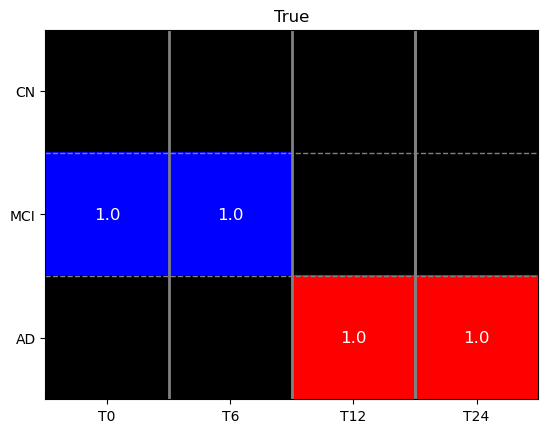

In [39]:
plot_output(y_true_img[0, :, :, :],y_true[0], "True" )

In [40]:
y_pred_img = create_image(y_pred)
y_pred_img[0,:,:,:]


array([[[0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        ]],

       [[0.        , 0.        , 0.98000002],
        [0.        , 0.        , 0.73000002],
        [0.        , 0.        , 0.56999999],
        [0.        , 0.        , 0.41      ]],

       [[0.02      , 0.        , 0.        ],
        [0.27000001, 0.        , 0.        ],
        [0.43000001, 0.        , 0.        ],
        [0.58999997, 0.        , 0.        ]]])

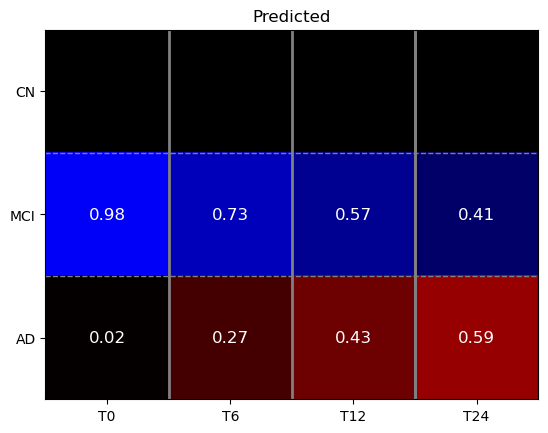

In [41]:
plot_output(y_pred_img[0,:,:,:],y_pred[0], "Predicted" )

In [42]:
X_test_here_names

array([ 719, 3426, 3064, 3645, 1324, 3033, 2841,  247, 3841, 3048, 2468,
        433, 2859, 1649,   57,  906, 1707, 2448, 4943, 2390, 5547,  826,
       4485, 3672,  319, 4915, 1730, 3903, 3810, 4492,  116, 3250,  162,
       2317, 4789, 5234, 5260, 4913, 2559, 3990,  453, 4874, 1650, 3655,
       2743, 1764, 3009, 3405, 5360,  954, 1210, 4393, 2396,   55, 4147,
       5237,  118, 1245,  447, 4362, 4509, 5345, 4691, 1194, 1741, 2980,
       4875, 2917, 2523, 1740, 2687, 2652, 4072, 3356, 4204, 2588, 1719,
       2070,  501, 2776, 4885,  276,  290, 1138, 3781, 1747, 1123, 1666,
       2569, 1043, 5133,  403, 3471, 5649, 4944,  180, 1391, 2435, 3716,
       1963, 1376, 4405,  831, 2168, 4933,  890, 5402, 5297, 1375, 3149,
       3695, 2117, 2306, 4155, 5363, 5202,   84, 5612, 3831, 5411,  434,
        699, 4580, 2939, 3893, 4057, 5534, 2457, 4917, 4227, 1812, 3837,
       2210, 3952, 4717,  597, 4122, 5553, 5441, 1648,  808, 2173, 2387,
       5154, 1283, 5010, 5447, 1142,  245, 3568, 12

In [43]:
X_test_here_names[0]

719

In [44]:
AllDataset.iloc[718]

ID                719
RID               258
PTID       128_S_0258
VISCODE            12
SITE              128
              ...    
DX6               MCI
12             258m24
DX12         Dementia
24             258m36
DX24         Dementia
Name: 719, Length: 69, dtype: object

In [45]:
AllDataset.iloc[X_test_here_names[1]]["ID"]

3427

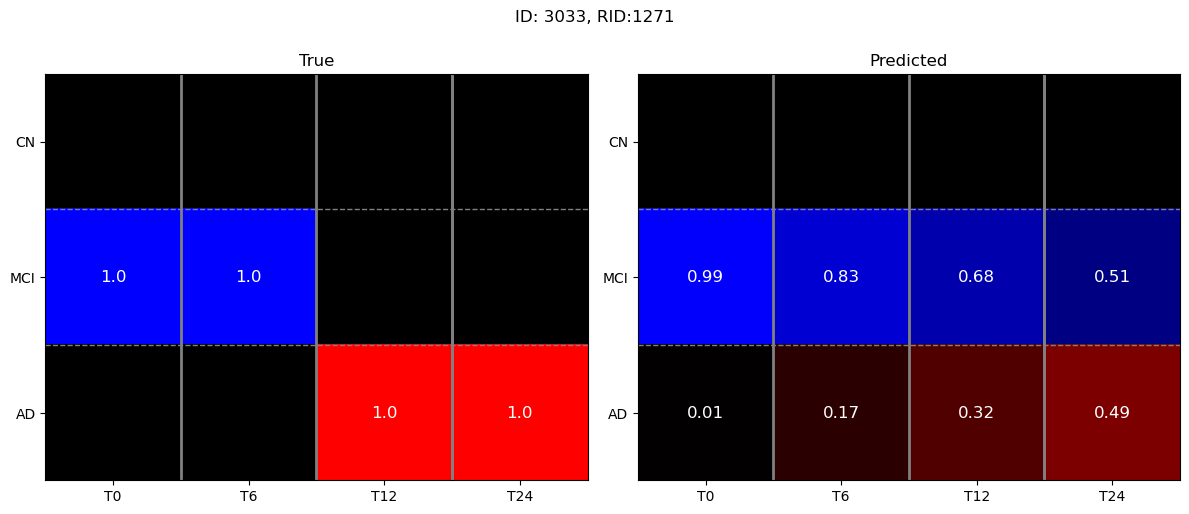

In [49]:
index = 5
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle(f"ID: {X_test_here_names[index]}, RID:{AllDataset.loc[AllDataset['ID'] == X_test_here_names[index], 'RID'].values[0]}")

plt.sca(axes[0])
plot_output(y_true_img[index, :, :, :], y_true[index], "True")

plt.sca(axes[1])
plot_output(y_pred_img[index, :, :, :], y_pred[index], "Predicted")
plt.tight_layout(rect=[0, 0, 1, 0.95]) 

plt.show()

In [98]:
len(X_test_here_names)

566

In [100]:
for index in range(len(X_test_here_names)):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    fig.suptitle(f"ID: {X_test_here_names[index]}, RID:{AllDataset.loc[AllDataset['ID'] == X_test_here_names[index], 'RID'].values[0]}")

    plt.sca(axes[0])
    plot_output(y_true_img[index, :, :, :], y_true[index], "True")

    plt.sca(axes[1])
    plot_output(y_pred_img[index, :, :, :], y_pred[index], "Predicted")
    plt.tight_layout(rect=[0, 0, 1, 0.95]) 

    plt.savefig(f"test_images_imputed/{index}.jpg", format = 'jpg', dpi=300)
    plt.close()
    